# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab1 - Image classification using the Bag of Visual Words Model

2021-25 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this laboratory work is to solve an image classification problem using the Bag of Visual Words model for image representation.


We will learn how to
1.   Detect and describe keypoints using SIFT
2.   Create a dictionary of visual words
3.   Represent an image with a histogram of visual words
4.   Train and test an image classifier based on the BOW representation

In the first part of this notebook code is provided to solve the task using SIFT keypoints and a k-NN classifier.

Then, you will have to complete some tasks, changing some of the hyperparemeters, computing other metrics or using a different classifier.

Instructions:
1. You can work in teams of two.
2. There are five mandatory tasks.
3. Add and run your Python code and answer the questions in this same notebook.
5. Upload a zip file with the notebook (after running code cells, including results, confussion matrices, images, etc.) to Atenea.

---

### Write here your names

**Name1**: Marcel López López

**Name2**:

---

We will use a dataset of images and files with image names of the images for the training and test splits.

First, download from ATENEA the file BOW_data.zip. Upload it to the Colab notebook using the menu on the left.

You could also copy the file to your Google drive and mount your drive in the colaboratory environment using:
>from google.colab import drive

>drive.mount('/content/drive')


Unzip the file:

In [1]:
!unzip BOW_data.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: test/highway/bost317.jpg  
  inflating: __MACOSX/test/highway/._bost317.jpg  
  inflating: test/highway/gre41.jpg  
  inflating: __MACOSX/test/highway/._gre41.jpg  
  inflating: test/highway/gre55.jpg  
  inflating: __MACOSX/test/highway/._gre55.jpg  
  inflating: test/highway/art252.jpg  
  inflating: __MACOSX/test/highway/._art252.jpg  
  inflating: test/highway/gre45.jpg  
  inflating: __MACOSX/test/highway/._gre45.jpg  
  inflating: test/highway/bost313.jpg  
  inflating: __MACOSX/test/highway/._bost313.jpg  
  inflating: test/highway/bost307.jpg  
  inflating: __MACOSX/test/highway/._bost307.jpg  
  inflating: test/highway/gre414.jpg  
  inflating: __MACOSX/test/highway/._gre414.jpg  
  inflating: test/highway/bost306.jpg  
  inflating: __MACOSX/test/highway/._bost306.jpg  
  inflating: test/highway/bost299.jpg  
  inflating: __MACOSX/test/highway/._bost299.jpg  
  inflating: test/highway/bost311.jpg  
  inf

In [2]:
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

We read the train and test image names and labels

In [3]:
train_filenames = pickle.load(open('train_filenames.dat','rb'))
test_filenames = pickle.load(open('test_filenames.dat','rb'))
train_labels = pickle.load(open('train_labels.dat','rb'))
test_labels = pickle.load(open('test_labels.dat','rb'))

We will detect and describe keypoints using SIFT

But before creating the dictionary, let's compute and display the keypoints for a single sample image

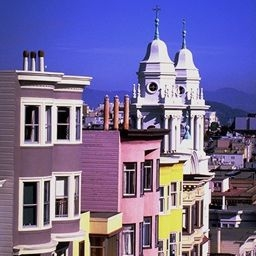

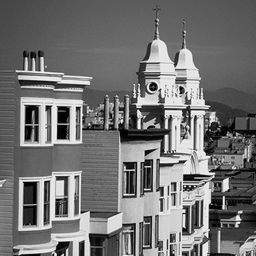

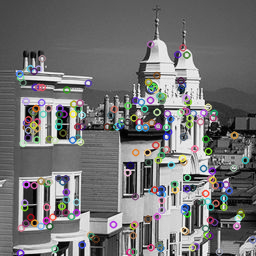

In [4]:
img = cv2.imread('train/inside_city/a48009.jpg')
cv2_imshow(img)

gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#SIFTdetector = cv2.xfeatures2d.SIFT_create(nfeatures=300)

SIFTdetector = cv2.SIFT_create(300)
kpt=SIFTdetector.detect(gray,None)
img2=cv2.drawKeypoints(gray,kpt,img)
cv2_imshow(img)

Now we start to create the dictionary of visual words by detecting keypoints and computing the SIFT descriptors for all the training images

In [5]:
Train_descriptors = []
Train_label_per_descriptor = []
for filename,labels in zip(train_filenames,train_labels):
    ima=cv2.imread(filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    Train_descriptors.append(des)
    Train_label_per_descriptor.append(labels)

D=np.vstack(Train_descriptors)

Next, we apply k-means clustering on the descriptor space. The cluster centers form the dictionary of visual words.

We will use `MiniBatchKMeans`, a variant of the KMeans algorithm which uses mini-batches to reduce the computation time.

`n_clusters` is the number of clusters or visual words in the dictionary. You can change this value to see the efect of using bigger or smaller dictionaries.

In [22]:
k = 128
codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
codebook.fit(D)
codebook.cluster_centers_

array([[18.387367 ,  9.309099 ,  7.917638 , ...,  6.253583 ,  5.2254915,
        12.035762 ],
       [22.689322 , 13.755258 , 10.690269 , ...,  8.262686 ,  5.9875255,
         9.107155 ],
       [21.30046  , 17.708506 , 19.156809 , ...,  9.980998 , 13.217172 ,
        15.56625  ],
       ...,
       [39.02345  , 26.023159 , 13.334544 , ...,  6.8306375,  4.7595005,
        10.003767 ],
       [22.040346 , 24.1888   , 22.185305 , ..., 29.614805 , 26.539452 ,
        24.658672 ],
       [75.845856 , 31.31417  ,  9.525182 , ...,  9.568417 ,  8.625163 ,
        15.684821 ]], dtype=float32)

For each training image, we project each keypoint descriptor to its closest visual word. We represent each of the images with the frequency of each visual word.

In [23]:
visual_words=np.zeros((len(Train_descriptors),k),dtype=np.float32)
for i in range(len(Train_descriptors)):
    words=codebook.predict(Train_descriptors[i])
    visual_words[i,:]=np.bincount(words,minlength=k)

We create a k-nn classifier and train it with the training set histograms (Note that we use 'knn = KNeighborsClassifier`to create the classifier, and knn.fit for t

In [24]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1,metric='euclidean')
knn.fit(visual_words, train_labels)

KNeighborsClassifier(metric='euclidean', n_jobs=-1)

We compute the histograms for the test images, classify and compute the accuracy

In [25]:
visual_words_test=np.zeros((len(test_filenames),k),dtype=np.float32)
for i in range(len(test_filenames)):
    filename=test_filenames[i]
    ima=cv2.imread(filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    words=codebook.predict(des)
    visual_words_test[i,:]=np.bincount(words,minlength=k)

In [26]:
print ('example of a histogram of visual words (representation of image i):')
print (visual_words_test[0,:])

example of a histogram of visual words (representation of image i):
[2. 6. 0. 0. 0. 3. 8. 0. 3. 3. 1. 0. 2. 3. 1. 1. 1. 2. 3. 1. 1. 4. 4. 1.
 3. 6. 6. 0. 0. 1. 3. 2. 3. 0. 2. 0. 2. 2. 4. 2. 3. 0. 4. 3. 1. 2. 0. 3.
 0. 5. 1. 1. 0. 2. 1. 0. 1. 1. 8. 0. 0. 2. 2. 3. 3. 1. 0. 0. 2. 4. 2. 4.
 3. 0. 0. 6. 2. 4. 1. 0. 3. 5. 3. 2. 1. 0. 8. 0. 1. 0. 3. 7. 0. 4. 1. 0.
 4. 1. 0. 1. 4. 1. 0. 0. 4. 0. 0. 5. 3. 1. 4. 1. 1. 2. 0. 0. 0. 2. 3. 1.
 1. 0. 2. 3. 0. 1. 2. 1.]


In [27]:
accuracy = 100*knn.score(visual_words_test, test_labels)
print(accuracy)

predicted_labels = knn.predict(visual_words_test)
accuracy2 = accuracy_score(test_labels, predicted_labels)
print(accuracy2)

53.159851301115246
0.5315985130111525


## Tasks



1. Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes? (import confusion_matrix or plot_confusion_matrix and balanced_accuracy_score from sklearn.metrics)
2. Test different codebook sizes and different values of neighbors in k-NN. Compare and report your best results.
3. Use a linear SVM classifier (use sklearn StandardScaler to standardize features).
4. Use another variants of SVM: (1) with RBF kernel and (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.
5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.
6. Conclusions: Write a few paragraphs summarizing your work, results and conclusions from this assignment






<font color=red>1.   Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes?

Import `confusion_matrix` or `plot_confusion_matrix` and `balanced_accuracy_score` from sklearn.metrics)</font><br>

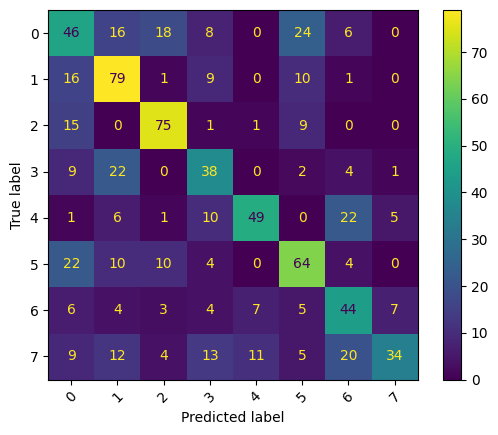

Balanced Accuracy: 0.5326167709987957

Recall per class:
Class Opencountry (0): 0.39
Class coast (1): 0.68
Class forest (2): 0.74
Class highway (3): 0.50
Class inside_city (4): 0.52
Class mountain (5): 0.56
Class street (6): 0.55
Class tallbuilding (7): 0.31


In [42]:
# Your code here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np
# I have imported ConfusionMatrixDisplay instead of plot_confusion_matrix beacuse it's depreciated

cm = confusion_matrix(test_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=45)
plt.show()

bal_acc = balanced_accuracy_score(test_labels, predicted_labels)
print("Balanced Accuracy:", bal_acc)

# Calculate recall in order to explain which are the easiest and the most dificult classes to predict
class_ids = np.unique(test_labels)
recall_per_class = cm.diagonal() / cm.sum(axis=1)
print("\nRecall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {class_ids[i]} ({i}): {r:.2f}")

<font color=blue>1. Answer: </br></br>
With the recall calculation we can confirm what we see in the confusion matrix. The classes that are easier to predict are classes 1 and 2, because they have the highest recall values. This means they are correctly classified more often than the others. This is probably because they contain distinctive and repetitive visual patterns that are well captured by the visual vocabulary.
<font color=blue></br></br>
On the other hand, the most difficult classes are class 7 and class 0, because they have the lowest recall values. This is interesting because if we only look at the confusion matrix, class 3 might seem worse (since it has a low number of correct predictions), but due to its smaller number of samples, its recall is actually around 50%, which is higher than classes 0 and 7.
</font><br></br>
The low performance of classes 0 and 7 is likely due to misclassification with other classes. This may be because these classes share visual similarities with others. For example, tall buildings may be confused with inside_city or street, while open country scenes may lack distinctive local features, making their representation less discriminative.
</font><br>

<font color=red>2.   Test different codebook sizes and different values of neighbors in k-NN.

Compare and report your best results. You can also try using different distances.</font><br>

In [45]:
# Your code here
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

k_values = [32, 64, 128, 256]
neighbors_values = [1, 3, 5, 7]
metrics = ['euclidean', 'manhattan']

results = []

le = LabelEncoder()
train_labels_enc = le.fit_transform(train_labels)
test_labels_enc = le.transform(test_labels)

for k in k_values:
    print(f"\n--- Codebook size: {k} ---")

    codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
    codebook.fit(D)

    visual_words = np.zeros((len(Train_descriptors), k), dtype=np.float32)
    for i in range(len(Train_descriptors)):
        words = codebook.predict(Train_descriptors[i])
        visual_words[i,:] = np.bincount(words, minlength=k)

    visual_words_test = np.zeros((len(test_filenames), k), dtype=np.float32)
    for i in range(len(test_filenames)):
        ima = cv2.imread(test_filenames[i])
        gray = cv2.cvtColor(ima, cv2.COLOR_BGR2GRAY)
        _, des = SIFTdetector.detectAndCompute(gray, None)
        words = codebook.predict(des)
        visual_words_test[i,:] = np.bincount(words, minlength=k)

    for n in neighbors_values:
        for metric in metrics:
            knn = KNeighborsClassifier(n_neighbors=n, metric=metric)
            knn.fit(visual_words, train_labels_enc)

            preds = knn.predict(visual_words_test)
            acc = accuracy_score(test_labels_enc, preds)

            results.append((k, n, metric, acc))
            print(f"k={k}, neighbors={n}, metric={metric} → acc={acc:.4f}")


--- Codebook size: 32 ---
k=32, neighbors=1, metric=euclidean → acc=0.4300
k=32, neighbors=1, metric=manhattan → acc=0.4325
k=32, neighbors=3, metric=euclidean → acc=0.4486
k=32, neighbors=3, metric=manhattan → acc=0.4511
k=32, neighbors=5, metric=euclidean → acc=0.4895
k=32, neighbors=5, metric=manhattan → acc=0.4808
k=32, neighbors=7, metric=euclidean → acc=0.4895
k=32, neighbors=7, metric=manhattan → acc=0.4895

--- Codebook size: 64 ---
k=64, neighbors=1, metric=euclidean → acc=0.4833
k=64, neighbors=1, metric=manhattan → acc=0.4895
k=64, neighbors=3, metric=euclidean → acc=0.4771
k=64, neighbors=3, metric=manhattan → acc=0.5006
k=64, neighbors=5, metric=euclidean → acc=0.5031
k=64, neighbors=5, metric=manhattan → acc=0.5229
k=64, neighbors=7, metric=euclidean → acc=0.5167
k=64, neighbors=7, metric=manhattan → acc=0.5229

--- Codebook size: 128 ---
k=128, neighbors=1, metric=euclidean → acc=0.5316
k=128, neighbors=1, metric=manhattan → acc=0.4932
k=128, neighbors=3, metric=euclide

<font color=blue>2. Answer:  </font><br><br>
<font color=blue>
We evaluated different codebook sizes and k-NN configurations. Increasing the codebook size generally improves performance up to a certain point, as it allows a more detailed representation of visual patterns. However, very large dictionaries may lead to overfitting and increased computational cost. This can be observed with the codebook size of 256, which performs worse than the intermediate values.
</font><br><br>
<font color=blue>
Regarding the number of neighbors, smaller values (e.g., k=1 or 3) tend to capture local structure better but may be more sensitive to noise, while larger values provide more stable and smoother decision boundaries. In this case, the best results are generally obtained with k=5 or k=7 depending on the codebook size.
</font><br><br>
<font color=blue>
In terms of distance metrics, Euclidean distance performed slightly better than Manhattan distance in most cases, especially for larger codebooks, as it better matches the geometric nature of the histogram space.
</font><br><br>
<font color=blue>
The best performance was obtained with a codebook size of 128 and k=7 neighbors using Euclidean distance, achieving an accuracy of 54.77%.
</font>


<font color=red>3. Use a linear SVM classifier. Use sklearn `StandardScaler` to standardize features (removing the mean and scaling to unit variance).</font><br>

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Your code here to compute the codebook and histograms for training images
k = 128
codebook = MiniBatchKMeans(n_clusters=k, verbose=False, batch_size=k * 20,compute_labels=False,reassignment_ratio=10**-4,random_state=42,n_init=3)
codebook.fit(D)

visual_words=np.zeros((len(Train_descriptors),k),dtype=np.float32)
for i in range(len(Train_descriptors)):
    words=codebook.predict(Train_descriptors[i])
    visual_words[i,:]=np.bincount(words,minlength=k)

# Your code here to compute the histograms for the test images
visual_words_test=np.zeros((len(test_filenames),k),dtype=np.float32)
for i in range(len(test_filenames)):
    filename=test_filenames[i]
    ima=cv2.imread(filename)
    gray=cv2.cvtColor(ima,cv2.COLOR_BGR2GRAY)
    kpt,des=SIFTdetector.detectAndCompute(gray,None)
    words=codebook.predict(des)
    visual_words_test[i,:]=np.bincount(words,minlength=k)

# Use StandardScaler to standardize features
scaler=StandardScaler()
scaler.fit(visual_words)
vw_train_sc= scaler.transform(visual_words)
vw_test_sc = scaler.transform(visual_words_test)

# Create and fit a svm classifier
svm = SVC(kernel='linear')
svm.fit(vw_train_sc, train_labels)

# Your code here to predict labels and compute metrics
preds = svm.predict(vw_test_sc)
acc = accuracy_score(test_labels, preds)
print("Linear SVM accuracy:", acc)


Linear SVM accuracy: 0.5563816604708798


<font color=blue>3. Answer:  </font><br><br>
<font color=blue>
A linear SVM classifier was trained using the Bag of Visual Words representation. Since SVM is sensitive to feature scaling, the histogram features were standardized using StandardScaler, which removes the mean and scales the data to unit variance.
</font><br><br>
<font color=blue>
The linear SVM learns a global decision boundary that separates classes in the feature space, while k-NN relies on local similarity between samples. However, in this case both approaches achieve very similar performance, suggesting that the BoVW representation already provides a relatively well-structured feature space where simple distance-based methods work effectively.
</font><br><br>
<font color=blue>
The obtained accuracy (0.556) is only slightly higher than the best k-NN configuration (0.548), indicating that the feature representation is a more limiting factor than the classifier itself.
</font>

<font color=red>4. Use another variants of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.</font><br>

In [50]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# StandardScaler
scaler = StandardScaler()
scaler.fit(visual_words)
vw_train_sc = scaler.transform(visual_words)
vw_test_sc = scaler.transform(visual_words_test)

# SVM con kernel RBF
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(vw_train_sc, train_labels)

pred_rbf = svm_rbf.predict(vw_test_sc)
acc_rbf = accuracy_score(test_labels, pred_rbf)

print("RBF SVM accuracy:", acc_rbf)

# Histogram Intersection Kernel
def histogram_intersection(X, Y):
    return np.array([[np.sum(np.minimum(x, y)) for y in Y] for x in X])

K_train = histogram_intersection(vw_train_sc, vw_train_sc)
K_test = histogram_intersection(vw_test_sc, vw_train_sc)

svm_hist = SVC(kernel='precomputed')
svm_hist.fit(K_train, train_labels)

pred_hist = svm_hist.predict(K_test)
acc_hist = accuracy_score(test_labels, pred_hist)

print("Histogram Intersection SVM accuracy:", acc_hist)

RBF SVM accuracy: 0.6641883519206939
Histogram Intersection SVM accuracy: 0.5997521685254027


<font color=blue>4. Answer:  </font><br><br>
<font color=blue>
In this exercise, two variants of SVM were evaluated: the RBF kernel and the histogram intersection kernel, using the same Bag of Visual Words representation and standardized features.
 </font><br><br>
<font color=blue>
The RBF SVM achieved an accuracy of 0.664, which is a significant improvement compared to both the linear SVM (0.556) and the best k-NN configuration (0.548). This suggests that introducing non-linearity helps to better separate the classes in the BoVW feature space, which is not perfectly linearly separable.
 </font><br><br>
<font color=blue>
The histogram intersection SVM obtained an accuracy of 0.600, also improving over k-NN and linear SVM, but performing worse than the RBF kernel. This is expected, since although histogram intersection is well suited for BoVW representations (as it directly measures overlap between histograms), it is still more limited than a fully non-linear kernel like RBF.
 </font><br><br>
<font color=blue>
Comparing all methods tested so far, k-NN and linear SVM provide very similar performance, while more advanced kernels such as RBF clearly improve results. However, the gains are moderate, which reinforces the idea that the main limitation of the system is not the classifier, but the Bag of Visual Words representation itself.
 </font>

<font color=red>5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.</font><br>


In [52]:
# Create Dense SIFT extractor
def dense_sift(gray, step_size=8, size=16):
    sift = cv2.SIFT_create()
    h, w = gray.shape
    keypoints = []
    for y in range(0, h, step_size):
        for x in range(0, w, step_size):
            keypoints.append(cv2.KeyPoint(x, y, size))
    keypoints, descriptors = sift.compute(gray, keypoints)
    return descriptors

# Create train descriptors
Train_descriptors_dense = []
for filename in train_filenames:
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    des = dense_sift(gray, step_size=8)
    if des is not None:
        Train_descriptors_dense.append(des)
D_dense = np.vstack(Train_descriptors_dense)

# Create visual dictionary
k = 128
codebook_dense = MiniBatchKMeans(n_clusters=k, batch_size=k * 20, random_state=42, n_init=3)
codebook_dense.fit(D_dense)

# Histogram train
visual_words_dense = np.zeros((len(Train_descriptors_dense), k), dtype=np.float32)
for i in range(len(Train_descriptors_dense)):
    words = codebook_dense.predict(Train_descriptors_dense[i])
    visual_words_dense[i, :] = np.bincount(words, minlength=k)

# Histogram test
visual_words_test_dense = np.zeros((len(test_filenames), k), dtype=np.float32)
for i in range(len(test_filenames)):
    img = cv2.imread(test_filenames[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    des = dense_sift(gray, step_size=8)
    if des is not None:
        words = codebook_dense.predict(des)
        visual_words_test_dense[i, :] = np.bincount(words, minlength=k)


# Standarization
scaler = StandardScaler()
scaler.fit(visual_words_dense)
X_train = scaler.transform(visual_words_dense)
X_test = scaler.transform(visual_words_test_dense)

# SVM linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, train_labels)
pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(test_labels, pred_linear)
print("Linear SVM:", acc_linear)

# SVM RBF
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, train_labels)
pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(test_labels, pred_rbf)
print("RBF SVM:", acc_rbf)

# Histogram intersection SVM
def histogram_intersection(X, Y):
    return np.array([[np.sum(np.minimum(x, y)) for y in Y] for x in X])
K_train = histogram_intersection(X_train, X_train)
K_test = histogram_intersection(X_test, X_train)
svm_hist = SVC(kernel='precomputed')
svm_hist.fit(K_train, train_labels)
pred_hist = svm_hist.predict(K_test)
acc_hist = accuracy_score(test_labels, pred_hist)
print("Histogram Intersection SVM:", acc_hist)

Linear SVM: 0.7831474597273854
RBF SVM: 0.8190830235439901
Histogram Intersection SVM: 0.815365551425031


<font color=blue>5. Answer:  </font><br><br>
<font color=blue>
In this experiment, Dense SIFT was used instead of the previously used keypoint-based SIFT. The main difference is that Dense SIFT extracts descriptors over a regular grid covering the entire image, instead of only focusing on interest points detected in specific regions. This means that more uniform and complete information is captured from each image, including areas that might be ignored by keypoint detection.
</font><br><br>
<font color=blue>
The results show a clear improvement compared to the previous approach using detected keypoints. With Dense SIFT, the best performance is achieved using the RBF SVM, reaching an accuracy of 0.819. The histogram intersection SVM also performs very well with 0.815, and even the linear SVM significantly improves to 0.783.
</font><br><br>
<font color=blue>
Compared to the previous results obtained with detected keypoints (where the best accuracy was around 0.66 with RBF SVM), Dense SIFT provides a substantial gain in performance. This confirms that the improvement is mainly due to a better feature representation rather than changes in the classifier.
</font><br><br>
<font color=blue>
Overall, Dense SIFT makes the Bag of Visual Words representation more robust by capturing richer spatial information, which leads to consistently better classification results across all tested models.
 </font>

<font color=blue>Conclusions:

Write a few paragraphs summarizing your work, results and conclussions from this assignment</font><br>

# Conclusions

## Overview of the approach

The work followed a progressive structure:

We first extracted SIFT descriptors from images using detected keypoints. These local descriptors were then used to build a visual vocabulary using K-Means clustering, also known as the codebook. Once the codebook was created, each image was represented as a histogram of visual words.

On top of this representation, we tested different classifiers: k-NN, linear SVM, and more advanced SVM variants using different kernels. Finally, we improved the feature extraction stage by replacing detected keypoints with Dense SIFT, which samples descriptors in a regular grid across the entire image.

---

## Results obtained

The first baseline using k-NN gave an accuracy around 0.55 with the best configuration (codebook size 128 and k=7). This already showed that the BoVW representation can capture useful information, but still has clear limitations.

When using a linear SVM, the performance remained very similar (around 0.556). This suggests that the feature space created by BoVW is already structured in a way that simple classifiers can handle, but it is not easily separable in a linear way.

Introducing non-linear SVMs improved the results more clearly. The RBF kernel achieved an accuracy of 0.664, while the histogram intersection kernel reached 0.600. This indicates that adding non-linearity helps to better separate classes in the histogram space, although the improvement is still moderate.

The biggest improvement came when using Dense SIFT instead of detected keypoints. In this case, the linear SVM reached 0.783, the histogram intersection SVM reached 0.815, and the RBF SVM achieved the best result with 0.819. This is a significant jump compared to all previous experiments.

---

## General discussion

Looking at all the results together, one clear pattern appears. Changing the classifier provides some improvements, especially when moving from linear to non-linear models, but the biggest impact comes from the feature extraction stage.

k-NN and linear SVM perform very similarly, which suggests that the BoVW representation already defines a reasonably structured feature space. However, it is still limited in terms of separability, which is why non-linear kernels help.

The most important improvement comes from Dense SIFT. By sampling features more uniformly across the image instead of relying only on keypoints, the representation becomes richer and more stable. This leads to a consistent improvement across all classifiers.

---

## 4. Final conclusion

Overall, this assignment shows that in classical computer vision pipelines based on BoVW, the quality of the feature representation is more important than the choice of classifier. While more advanced models like RBF SVM improve performance, the most significant gain comes from improving how images are described in the first place.